# Task B Phase-1 Variants: Training vs Validation Loss Comparison

This notebook compares the Phase-1 Task B variants by extracting the best available training/validation loss curves from the executed outputs in each notebook and plotting training loss in one panel and validation loss in the other.

## Step 1: Load notebook outputs

We will inspect the Phase-1 notebook outputs and collect the training/validation loss tables from the executed cells.

In [2]:
from pathlib import Path
import json
from io import StringIO

import pandas as pd
import matplotlib.pyplot as plt

base_dir = Path('/home/nikhita-ravi/procrastic-simulaters-SemEval-2026-Task13/src/task_B/Improved_models')
notebook_paths = [
    base_dir / 'task-b-phase-1 (1).ipynb',
    base_dir / 'task-b-phase-1 (overfitting-1).ipynb',
    base_dir / 'task-b-phase-1-3.ipynb',
]

print('Phase-1 notebooks to compare:')
for path in notebook_paths:
    print(f'  - {path.name} ({"found" if path.exists() else "missing"})')

Phase-1 notebooks to compare:
  - task-b-phase-1 (1).ipynb (found)
  - task-b-phase-1 (overfitting-1).ipynb (found)
  - task-b-phase-1-3.ipynb (found)


## Step 2: Extract loss curves

For each notebook, find the best validation-loss table and use its training and validation loss series for comparison.

In [3]:
def extract_candidate_tables(notebook_path):
    with open(notebook_path, 'r', encoding='utf-8') as handle:
        notebook = json.load(handle)

    candidates = []
    for cell in notebook.get('cells', []):
        if cell.get('cell_type') != 'code':
            continue
        for output in cell.get('outputs', []):
            html = None
            if 'data' in output and 'text/html' in output['data']:
                html = ''.join(output['data']['text/html'])
            elif 'text/html' in output:
                html = ''.join(output['text/html']) if isinstance(output['text/html'], list) else output['text/html']
            if not html:
                continue
            try:
                tables = pd.read_html(StringIO(html))
            except ValueError:
                continue
            for table in tables:
                normalized = {str(col).strip().lower(): col for col in table.columns}
                if {'step', 'training loss', 'validation loss'}.issubset(normalized):
                    candidates.append(table.copy())
    return candidates


def summarize_table(table):
    normalized = {str(col).strip().lower(): col for col in table.columns}
    step_col = normalized['step']
    train_col = normalized['training loss']
    val_col = normalized['validation loss']

    cleaned = table[[step_col, train_col, val_col]].copy()
    cleaned.columns = ['step', 'training_loss', 'validation_loss']
    cleaned = cleaned.dropna()
    cleaned['step'] = pd.to_numeric(cleaned['step'], errors='coerce')
    cleaned['training_loss'] = pd.to_numeric(cleaned['training_loss'], errors='coerce')
    cleaned['validation_loss'] = pd.to_numeric(cleaned['validation_loss'], errors='coerce')
    cleaned = cleaned.dropna()
    return cleaned


phase1_runs = []
missing_notebooks = []
for notebook_path in notebook_paths:
    candidates = extract_candidate_tables(notebook_path)
    if not candidates:
        missing_notebooks.append(notebook_path.name)
        continue

    scored = []
    for candidate in candidates:
        cleaned = summarize_table(candidate)
        if cleaned.empty:
            continue
        scored.append((cleaned['validation_loss'].min(), cleaned))

    if not scored:
        missing_notebooks.append(notebook_path.name)
        continue

    best_val, best_table = min(scored, key=lambda item: item[0])
    phase1_runs.append({
        'notebook': notebook_path.stem,
        'table': best_table,
        'best_val_loss': float(best_val),
        'best_step': float(best_table.loc[best_table['validation_loss'].idxmin(), 'step'])
    })

    print(f"{notebook_path.name}: selected curve with best validation loss = {best_val:.6f}")
    print(best_table.head())
    print('-' * 80)

print(f'Loaded {len(phase1_runs)} representative Phase-1 curves.')
if missing_notebooks:
    print('No completed loss tables were found in:')
    for notebook_name in missing_notebooks:
        print(f'  - {notebook_name}')

task-b-phase-1 (overfitting-1).ipynb: selected curve with best validation loss = 0.369342
   step  training_loss  validation_loss
0   811         1.3076         0.558454
1  1622         1.0140         0.369342
--------------------------------------------------------------------------------
task-b-phase-1-3.ipynb: selected curve with best validation loss = 0.369342
   step  training_loss  validation_loss
0   811         1.3076         0.558454
1  1622         1.0140         0.369342
--------------------------------------------------------------------------------
Loaded 2 representative Phase-1 curves.
No completed loss tables were found in:
  - task-b-phase-1 (1).ipynb


## Step 3: Plot training and validation loss

Training loss is shown on the left, and validation loss is shown on the right.

Saved plot to: /home/nikhita-ravi/procrastic-simulaters-SemEval-2026-Task13/src/task_B/Improved_models/phase1_training_validation_loss_comparison.png

Best representative curve per notebook:
                      Notebook  Best Step Best Val Loss Final Train Loss Final Val Loss  Points
task-b-phase-1 (overfitting-1)       1622      0.369342         1.014000       0.369342       2
              task-b-phase-1-3       1622      0.369342         1.014000       0.369342       2


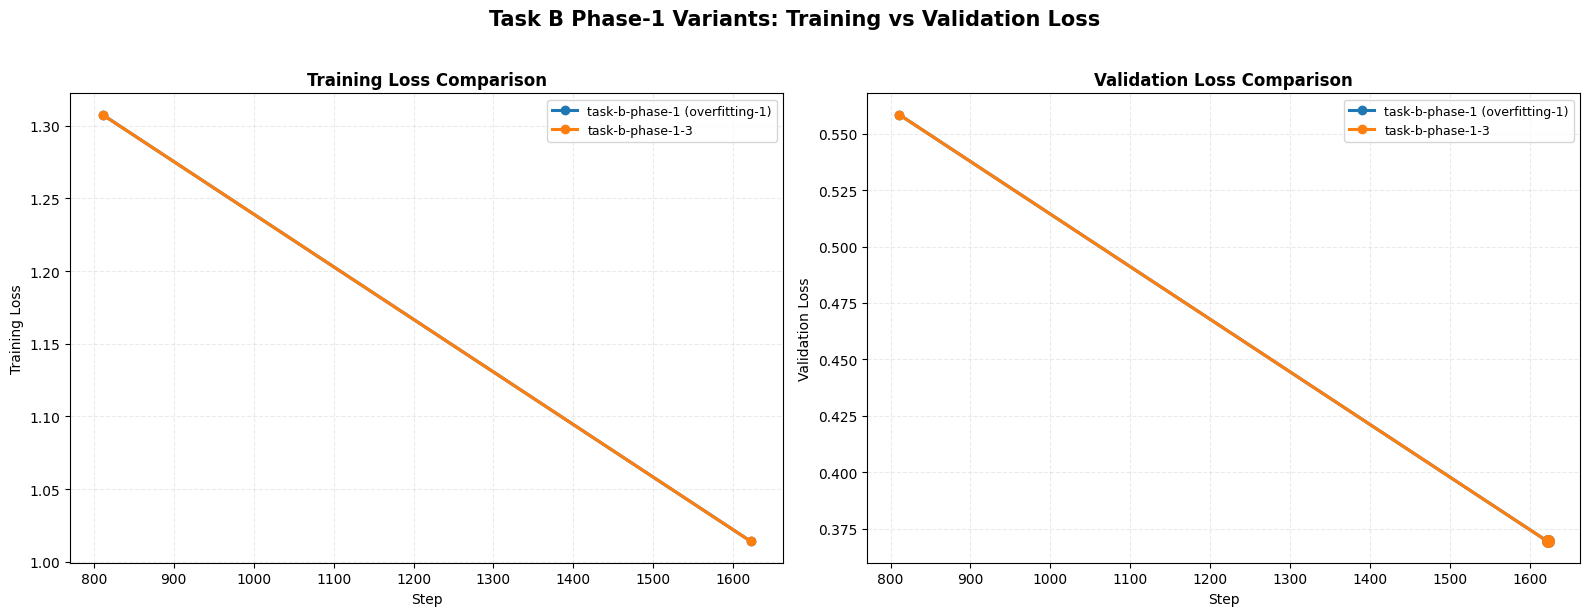

In [4]:
if not phase1_runs:
    raise RuntimeError('No Phase-1 loss curves were extracted from the notebooks.')

palette = ['#1f77b4', '#ff7f0e', '#2ca02c']
summary_rows = []

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=False)

for idx, run in enumerate(phase1_runs):
    curve = run['table']
    color = palette[idx % len(palette)]
    label = run['notebook']

    axes[0].plot(curve['step'], curve['training_loss'], marker='o', linewidth=2.2, color=color, label=label)
    axes[1].plot(curve['step'], curve['validation_loss'], marker='o', linewidth=2.2, color=color, label=label)

    best_idx = curve['validation_loss'].idxmin()
    best_step = float(curve.loc[best_idx, 'step'])
    best_val_loss = float(curve.loc[best_idx, 'validation_loss'])
    final_train_loss = float(curve['training_loss'].iloc[-1])
    final_val_loss = float(curve['validation_loss'].iloc[-1])

    summary_rows.append({
        'Notebook': label,
        'Best Step': int(best_step),
        'Best Val Loss': best_val_loss,
        'Final Train Loss': final_train_loss,
        'Final Val Loss': final_val_loss,
        'Points': len(curve),
    })

    axes[1].scatter([best_step], [best_val_loss], color=color, s=70, zorder=5)

for ax, title, ylabel in [
    (axes[0], 'Training Loss Comparison', 'Training Loss'),
    (axes[1], 'Validation Loss Comparison', 'Validation Loss'),
]:
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Step')
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.25, linestyle='--')
    ax.legend(fontsize=9)

plt.suptitle('Task B Phase-1 Variants: Training vs Validation Loss', fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()

plot_path = base_dir / 'phase1_training_validation_loss_comparison.png'
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f'Saved plot to: {plot_path}')

summary_df = pd.DataFrame(summary_rows).sort_values('Best Val Loss')
print('\nBest representative curve per notebook:')
print(summary_df.to_string(index=False, formatters={
    'Best Val Loss': '{:.6f}'.format,
    'Final Train Loss': '{:.6f}'.format,
    'Final Val Loss': '{:.6f}'.format,
}))

plt.show()

## Step 4: HP-search loss ablation (all trials)

Extract all 7 HP-search trial tables from Phase-1 notebooks and visualize training/validation loss across the (lr, max_length) grid. This shows how hyperparameters affect loss trajectories.

In [17]:
def extract_all_trial_tables(notebook_path, hp_search_only=True):
    """Extract loss-table candidates from a notebook.

    When hp_search_only=True, only parse the HP-search code cell
    (the one with SEARCH_GRID / TRIAL loop), so final-training tables
    are not mixed into HP ablation plots.
    """
    with open(notebook_path, 'r', encoding='utf-8') as handle:
        notebook = json.load(handle)

    trials = []
    for cell_idx, cell in enumerate(notebook.get('cells', [])):
        if cell.get('cell_type') != 'code':
            continue

        source_text = ''.join(cell.get('source', []))
        if hp_search_only:
            is_hp_cell = (
                'SEARCH_GRID' in source_text
                and 'for lr in SEARCH_GRID' in source_text
                and 'for ml in SEARCH_GRID' in source_text
            )
            if not is_hp_cell:
                continue

        for output in cell.get('outputs', []):
            html = None
            if 'data' in output and 'text/html' in output['data']:
                html = ''.join(output['data']['text/html'])
            elif 'text/html' in output:
                html = ''.join(output['text/html']) if isinstance(output['text/html'], list) else output['text/html']
            if not html:
                continue
            try:
                tables = pd.read_html(StringIO(html))
            except ValueError:
                continue
            for table_idx, table in enumerate(tables):
                normalized = {str(col).strip().lower(): col for col in table.columns}
                if {'step', 'training loss', 'validation loss'}.issubset(normalized):
                    cleaned = summarize_table(table)
                    if not cleaned.empty:
                        trials.append(cleaned)

    # Deduplicate identical tables (sometimes repeated in notebook outputs)
    unique_trials = []
    seen = set()
    for trial in trials:
        signature = tuple(
            zip(
                trial['step'].astype(int).tolist(),
                trial['training_loss'].round(8).tolist(),
                trial['validation_loss'].round(8).tolist(),
            )
        )
        if signature in seen:
            continue
        seen.add(signature)
        unique_trials.append(trial.reset_index(drop=True))

    return unique_trials


# Extract all HP-search trial tables from Phase-1 notebooks
all_phase1_trials = {}
for notebook_path in notebook_paths:
    if not notebook_path.exists():
        continue
    trials = extract_all_trial_tables(notebook_path, hp_search_only=True)
    if trials:
        all_phase1_trials[notebook_path.stem] = trials
        print(f"{notebook_path.name}: found {len(trials)} unique HP-search loss-table trials")

print(f'\nTotal HP-search trials extracted: {sum(len(v) for v in all_phase1_trials.values())}')
for name, trials in all_phase1_trials.items():
    if trials:
        print(f"  {name}: {len(trials)} unique trials")
        for i, trial in enumerate(trials[:3]):  # preview first 3
            print(f"    Trial {i+1}: {len(trial)} loss points, best_val={trial['validation_loss'].min():.6f}")


task-b-phase-1 (overfitting-1).ipynb: found 6 unique HP-search loss-table trials
task-b-phase-1-3.ipynb: found 6 unique HP-search loss-table trials

Total HP-search trials extracted: 12
  task-b-phase-1 (overfitting-1): 6 unique trials
    Trial 1: 3 loss points, best_val=0.576012
    Trial 2: 3 loss points, best_val=0.499262
    Trial 3: 3 loss points, best_val=0.502290
  task-b-phase-1-3: 6 unique trials
    Trial 1: 3 loss points, best_val=0.576012
    Trial 2: 3 loss points, best_val=0.499262
    Trial 3: 3 loss points, best_val=0.502290


Saved HP-search ablation plot to: /home/nikhita-ravi/procrastic-simulaters-SemEval-2026-Task13/src/task_B/Improved_models/phase1_hp_search_ablation.png

HP-Search Trial Rankings (sorted by best validation loss):
 Rank  Trial Best Val Loss Final Train Loss Final Val Loss  Points
    1      6      0.369342         1.014000       0.369342       2
    2      4      0.433558         1.097600       0.433558       3
    3      5      0.472883         1.120300       0.481493       3
    4      2      0.499262         1.292100       0.509697       3
    5      3      0.502290         1.260000       0.505927       3
    6      1      0.576012         1.384500       0.576012       3


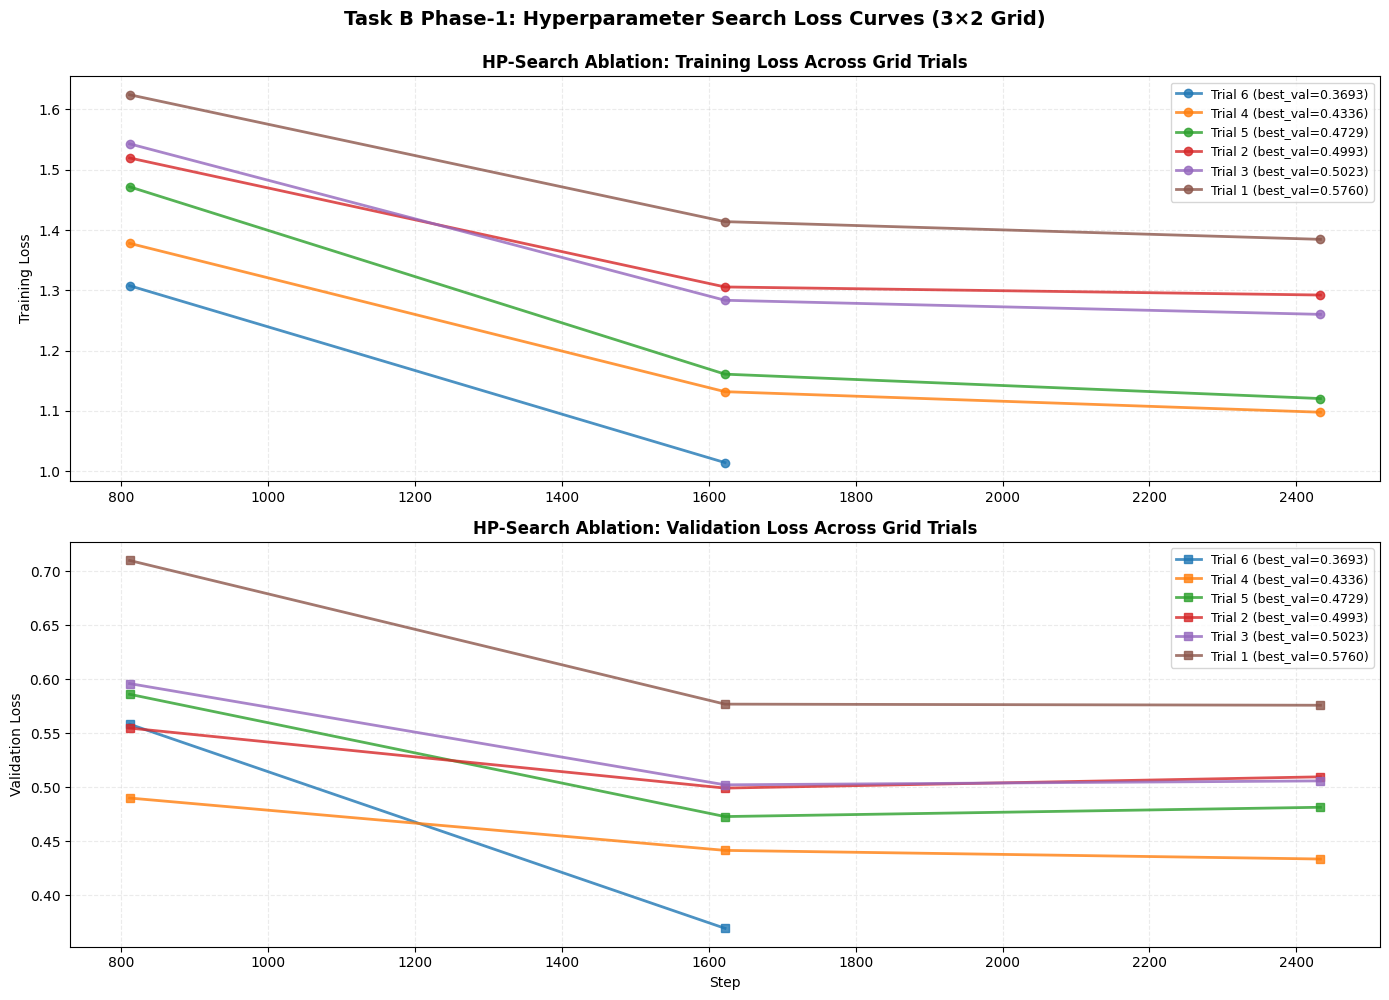

In [18]:
# Create HP-search ablation plots for the main Phase-1 variant
if 'task-b-phase-1-3' in all_phase1_trials and len(all_phase1_trials['task-b-phase-1-3']) > 1:
    trials = all_phase1_trials['task-b-phase-1-3']

    # HP grid is 3 x 2 => expected 6 trials
    expected_trials = 6
    if len(trials) != expected_trials:
        print(f"⚠️ Expected {expected_trials} HP trials, extracted {len(trials)} after filtering.")

    # Sort by validation loss to rank trials
    trial_scores = [(i, t['validation_loss'].min()) for i, t in enumerate(trials)]
    trial_scores.sort(key=lambda x: x[1])

    # Create a 2-row subplot grid (training and validation loss)
    n_trials = len(trials)
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    colors = plt.cm.tab10(range(n_trials))

    for rank, (trial_idx, best_val) in enumerate(trial_scores):
        trial = trials[trial_idx]
        color = colors[rank]
        label = f'Trial {trial_idx+1} (best_val={best_val:.4f})'

        # Training loss
        axes[0].plot(
            trial['step'],
            trial['training_loss'],
            marker='o',
            linewidth=2.0,
            color=color,
            label=label,
            alpha=0.8,
        )

        # Validation loss
        axes[1].plot(
            trial['step'],
            trial['validation_loss'],
            marker='s',
            linewidth=2.0,
            color=color,
            label=label,
            alpha=0.8,
        )

    # Formatting
    axes[0].set_title('HP-Search Ablation: Training Loss Across Grid Trials', fontweight='bold', fontsize=12)
    axes[0].set_ylabel('Training Loss')
    axes[0].grid(True, alpha=0.25, linestyle='--')
    axes[0].legend(fontsize=9, loc='best')

    axes[1].set_title('HP-Search Ablation: Validation Loss Across Grid Trials', fontweight='bold', fontsize=12)
    axes[1].set_xlabel('Step')
    axes[1].set_ylabel('Validation Loss')
    axes[1].grid(True, alpha=0.25, linestyle='--')
    axes[1].legend(fontsize=9, loc='best')

    plt.suptitle(
        'Task B Phase-1: Hyperparameter Search Loss Curves (3×2 Grid)',
        fontweight='bold',
        fontsize=14,
        y=0.995,
    )
    plt.tight_layout()

    ablation_plot_path = base_dir / 'phase1_hp_search_ablation.png'
    plt.savefig(ablation_plot_path, dpi=300, bbox_inches='tight')
    print(f'Saved HP-search ablation plot to: {ablation_plot_path}')

    # Print trial summary
    ablation_summary = []
    for rank, (trial_idx, best_val) in enumerate(trial_scores):
        trial = trials[trial_idx]
        ablation_summary.append({
            'Rank': rank + 1,
            'Trial': trial_idx + 1,
            'Best Val Loss': best_val,
            'Final Train Loss': trial['training_loss'].iloc[-1],
            'Final Val Loss': trial['validation_loss'].iloc[-1],
            'Points': len(trial),
        })

    print('\nHP-Search Trial Rankings (sorted by best validation loss):')
    ablation_summary_df = pd.DataFrame(ablation_summary)
    print(
        ablation_summary_df.to_string(
            index=False,
            formatters={
                'Best Val Loss': '{:.6f}'.format,
                'Final Train Loss': '{:.6f}'.format,
                'Final Val Loss': '{:.6f}'.format,
            },
        )
    )

    plt.show()
else:
    print('⚠️ Not enough Phase-1 HP-search trials found for ablation analysis.')

## Step 5: Overfitting-gap analysis

Compute and visualize the overfitting gap (validation_loss - training_loss) for the best Phase-1 run. This shows how the train/validation gap widens (or closes) as training progresses.

Best Phase-1 trial: Trial 6
  Best validation loss: 0.369342
  Best training loss: 1.014000
  Max overfitting gap: -0.644658
  Min overfitting gap: -0.749146

Overfitting gap progression:
 step training_loss validation_loss overfitting_gap
  811      1.307600        0.558454       -0.749146
 1622      1.014000        0.369342       -0.644658

Saved overfitting gap plot to: /home/nikhita-ravi/procrastic-simulaters-SemEval-2026-Task13/src/task_B/Improved_models/phase1_overfitting_gap.png


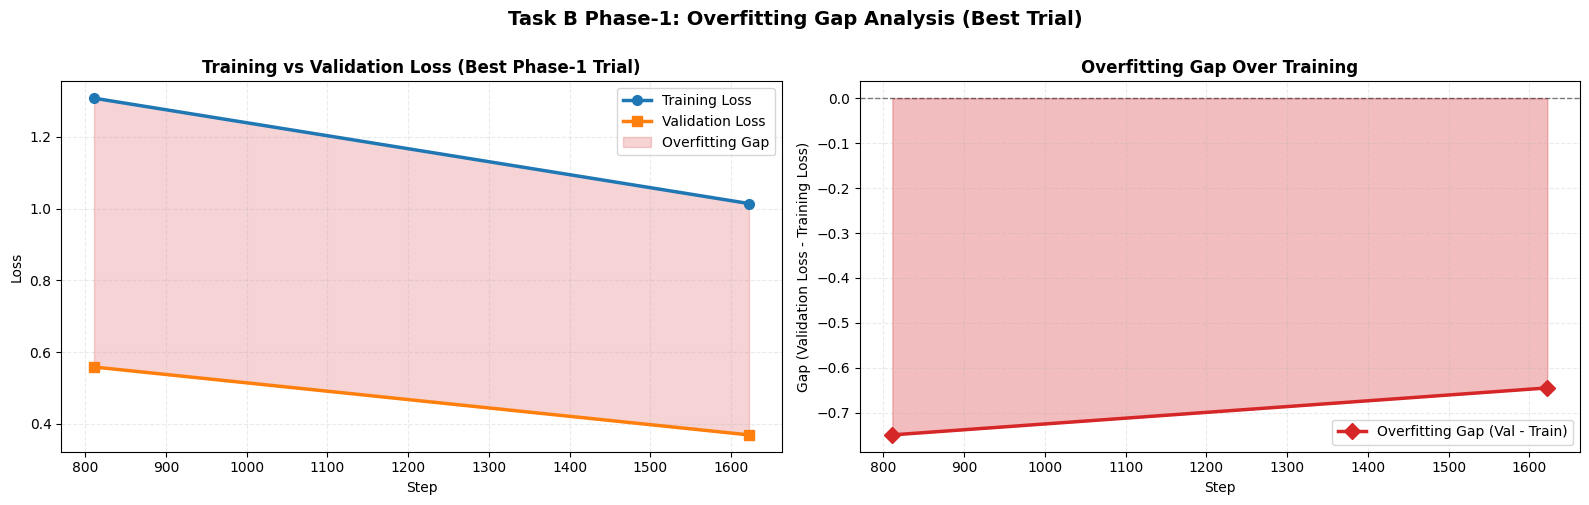

In [7]:
# Compute overfitting gap for the best Phase-1 run
if 'task-b-phase-1-3' in all_phase1_trials:
    trials = all_phase1_trials['task-b-phase-1-3']
    
    # Find the trial with the lowest validation loss (best trial)
    best_trial_idx = min(range(len(trials)), key=lambda i: trials[i]['validation_loss'].min())
    best_trial = trials[best_trial_idx]
    
    # Compute overfitting gap: Δ = validation_loss - training_loss
    best_trial['overfitting_gap'] = best_trial['validation_loss'] - best_trial['training_loss']
    
    print(f'Best Phase-1 trial: Trial {best_trial_idx + 1}')
    print(f'  Best validation loss: {best_trial["validation_loss"].min():.6f}')
    print(f'  Best training loss: {best_trial["training_loss"].min():.6f}')
    print(f'  Max overfitting gap: {best_trial["overfitting_gap"].max():.6f}')
    print(f'  Min overfitting gap: {best_trial["overfitting_gap"].min():.6f}')
    print(f'\nOverfitting gap progression:')
    print(best_trial[['step', 'training_loss', 'validation_loss', 'overfitting_gap']].to_string(index=False, 
                                                                                                   formatters={
        'training_loss': '{:.6f}'.format,
        'validation_loss': '{:.6f}'.format,
        'overfitting_gap': '{:.6f}'.format,
    }))
    
    # Create overfitting gap visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Left: all three loss curves
    color_train, color_val, color_gap = '#1f77b4', '#ff7f0e', '#d62728'
    ax = axes[0]
    ax.plot(best_trial['step'], best_trial['training_loss'], marker='o', linewidth=2.5, 
            color=color_train, label='Training Loss', markersize=7)
    ax.plot(best_trial['step'], best_trial['validation_loss'], marker='s', linewidth=2.5, 
            color=color_val, label='Validation Loss', markersize=7)
    ax.fill_between(best_trial['step'], best_trial['training_loss'], best_trial['validation_loss'],
                    alpha=0.2, color=color_gap, label='Overfitting Gap')
    ax.set_title('Training vs Validation Loss (Best Phase-1 Trial)', fontweight='bold')
    ax.set_xlabel('Step')
    ax.set_ylabel('Loss')
    ax.grid(True, alpha=0.25, linestyle='--')
    ax.legend(fontsize=10)
    
    # Right: overfitting gap curve
    ax = axes[1]
    ax.plot(best_trial['step'], best_trial['overfitting_gap'], marker='D', linewidth=2.5, 
            color=color_gap, markersize=8, label='Overfitting Gap (Val - Train)')
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.fill_between(best_trial['step'], best_trial['overfitting_gap'], 0, alpha=0.3, color=color_gap)
    ax.set_title('Overfitting Gap Over Training', fontweight='bold')
    ax.set_xlabel('Step')
    ax.set_ylabel('Gap (Validation Loss - Training Loss)')
    ax.grid(True, alpha=0.25, linestyle='--')
    ax.legend(fontsize=10)
    
    plt.suptitle('Task B Phase-1: Overfitting Gap Analysis (Best Trial)', fontweight='bold', fontsize=14, y=1.00)
    plt.tight_layout()
    
    gap_plot_path = base_dir / 'phase1_overfitting_gap.png'
    plt.savefig(gap_plot_path, dpi=300, bbox_inches='tight')
    print(f'\nSaved overfitting gap plot to: {gap_plot_path}')
    
    plt.show()
else:
    print('⚠️ Phase-1-3 trials not found for overfitting-gap analysis.')


## Step 6: GraphCodeBERT baseline vs improved

Compare the best available loss curves from the GraphCodeBERT baseline notebook and the improved GraphCodeBERT notebook.

Baseline source: graphcodebert_task_b_baseline.ipynb
Improved source: taskb-best-performing-model.ipynb
Baseline best validation loss: 1.524922
Improved best validation loss: 0.938908
Delta (baseline - improved): 0.586014
Saved plot to: /home/nikhita-ravi/procrastic-simulaters-SemEval-2026-Task13/src/task_B/Improved_models/graphcodebert_baseline_vs_improved_loss.png


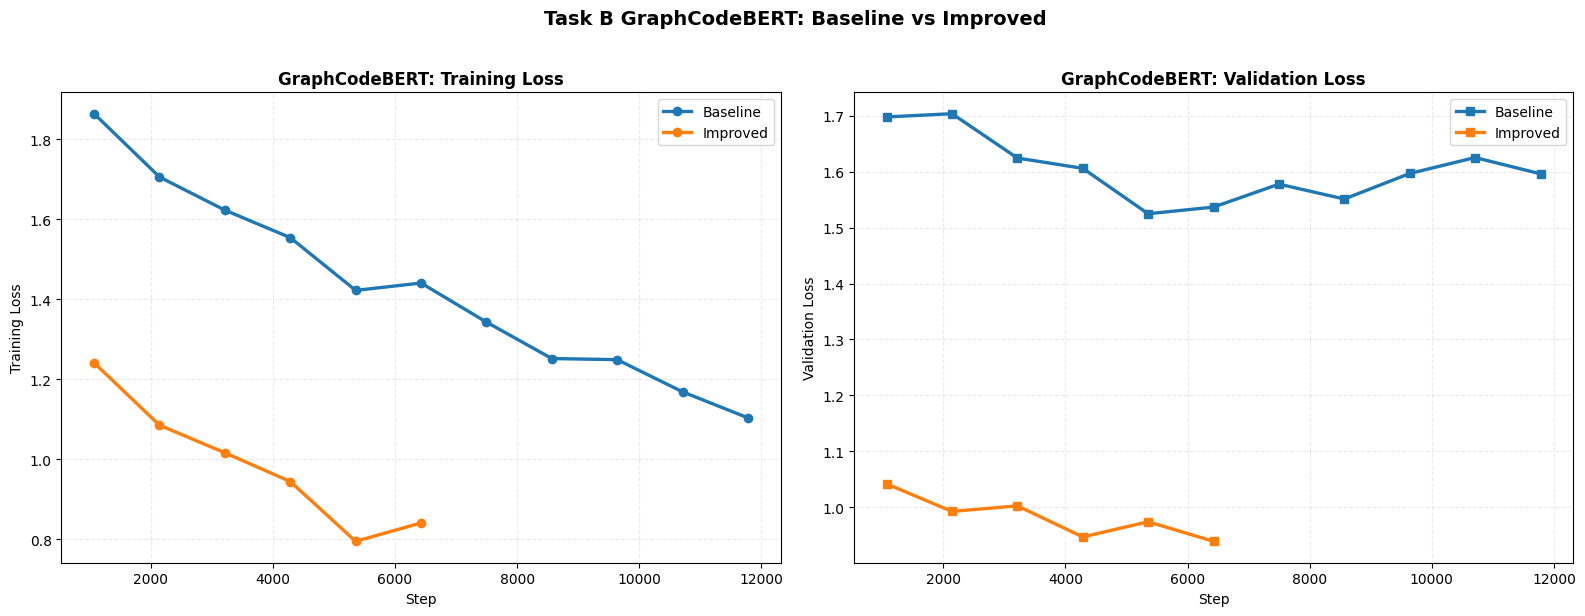

In [9]:
from pathlib import Path
import json
from io import StringIO

import pandas as pd
import matplotlib.pyplot as plt


def extract_graphcodebert_best_curve(notebook_path: Path) -> pd.DataFrame:
    with open(notebook_path, 'r', encoding='utf-8') as handle:
        notebook = json.load(handle)

    candidates = []
    for cell in notebook.get('cells', []):
        if cell.get('cell_type') != 'code':
            continue
        for output in cell.get('outputs', []):
            html = None
            if 'data' in output and 'text/html' in output['data']:
                html = ''.join(output['data']['text/html'])
            elif 'text/html' in output:
                html = ''.join(output['text/html']) if isinstance(output['text/html'], list) else output['text/html']
            if not html:
                continue
            try:
                tables = pd.read_html(StringIO(html))
            except ValueError:
                continue

            for table in tables:
                normalized = {str(col).strip().lower(): col for col in table.columns}
                if {'step', 'training loss', 'validation loss'}.issubset(normalized):
                    step_col = normalized['step']
                    train_col = normalized['training loss']
                    val_col = normalized['validation loss']

                    cleaned = table[[step_col, train_col, val_col]].copy()
                    cleaned.columns = ['step', 'training_loss', 'validation_loss']
                    cleaned = cleaned.dropna()
                    cleaned['step'] = pd.to_numeric(cleaned['step'], errors='coerce')
                    cleaned['training_loss'] = pd.to_numeric(cleaned['training_loss'], errors='coerce')
                    cleaned['validation_loss'] = pd.to_numeric(cleaned['validation_loss'], errors='coerce')
                    cleaned = cleaned.dropna()

                    if not cleaned.empty:
                        candidates.append(cleaned)

    if not candidates:
        return None

    best_curve = min(candidates, key=lambda df: df['validation_loss'].min())
    return best_curve.sort_values('step').reset_index(drop=True)


base_dir = Path('/home/nikhita-ravi/procrastic-simulaters-SemEval-2026-Task13/src/task_B/Improved_models')
baseline_notebook = base_dir / 'GraphCodeBert' / 'graphcodebert_task_b_baseline.ipynb'
improved_candidates = [
    base_dir / 'graphcodebert_task_b_improved.ipynb',
    base_dir / 'taskb-best-performing-model.ipynb',
    base_dir / 'Task-B-Improved.ipynb',
]

if not baseline_notebook.exists():
    raise FileNotFoundError('Baseline GraphCodeBERT notebook is missing.')

baseline_curve = extract_graphcodebert_best_curve(baseline_notebook)
if baseline_curve is None:
    raise RuntimeError(f'No loss curve table found in {baseline_notebook.name}')

improved_curve = None
improved_notebook = None
for candidate in improved_candidates:
    if not candidate.exists():
        continue
    curve = extract_graphcodebert_best_curve(candidate)
    if curve is not None:
        improved_curve = curve
        improved_notebook = candidate
        break

if improved_curve is None:
    raise RuntimeError('No improved GraphCodeBERT notebook had extractable loss-curve tables.')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(baseline_curve['step'], baseline_curve['training_loss'], marker='o', linewidth=2.4, label='Baseline')
axes[0].plot(improved_curve['step'], improved_curve['training_loss'], marker='o', linewidth=2.4, label='Improved')
axes[0].set_title('GraphCodeBERT: Training Loss', fontweight='bold')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Training Loss')
axes[0].grid(True, alpha=0.25, linestyle='--')
axes[0].legend()

axes[1].plot(baseline_curve['step'], baseline_curve['validation_loss'], marker='s', linewidth=2.4, label='Baseline')
axes[1].plot(improved_curve['step'], improved_curve['validation_loss'], marker='s', linewidth=2.4, label='Improved')
axes[1].set_title('GraphCodeBERT: Validation Loss', fontweight='bold')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Validation Loss')
axes[1].grid(True, alpha=0.25, linestyle='--')
axes[1].legend()

plt.suptitle('Task B GraphCodeBERT: Baseline vs Improved', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()

compare_plot_path = base_dir / 'graphcodebert_baseline_vs_improved_loss.png'
plt.savefig(compare_plot_path, dpi=300, bbox_inches='tight')

baseline_best = baseline_curve['validation_loss'].min()
improved_best = improved_curve['validation_loss'].min()
print(f'Baseline source: {baseline_notebook.name}')
print(f'Improved source: {improved_notebook.name}')
print(f'Baseline best validation loss: {baseline_best:.6f}')
print(f'Improved best validation loss: {improved_best:.6f}')
print(f'Delta (baseline - improved): {baseline_best - improved_best:.6f}')
print(f'Saved plot to: {compare_plot_path}')

plt.show()

Saved architecture diagram (PNG): /home/nikhita-ravi/procrastic-simulaters-SemEval-2026-Task13/src/task_B/Improved_models/taskb_best_model_architecture_small.png
Saved architecture diagram (SVG): /home/nikhita-ravi/procrastic-simulaters-SemEval-2026-Task13/src/task_B/Improved_models/taskb_best_model_architecture_small.svg


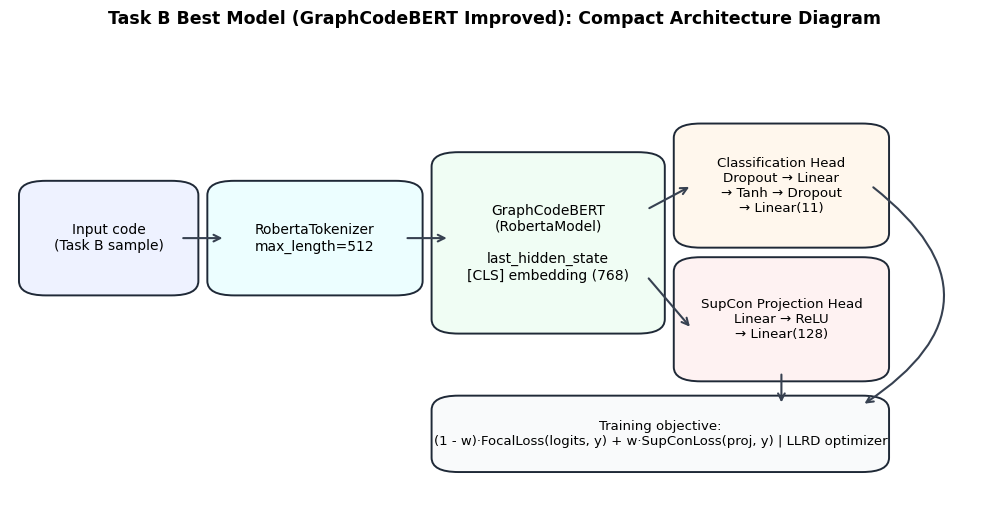

In [16]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch


def draw_box(ax, x, y, w, h, text, fc='#f8f9fa', ec='#1f2937', fontsize=10, lw=1.4):
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle='round,pad=0.02,rounding_size=0.03',
        linewidth=lw, edgecolor=ec, facecolor=fc
    )
    ax.add_patch(box)
    ax.text(
        x + w / 2,
        y + h / 2,
        text,
        ha='center',
        va='center',
        fontsize=fontsize,
        wrap=True,
    )
    return box


def draw_arrow(ax, x1, y1, x2, y2, color='#374151', connectionstyle='arc3,rad=0.0'):
    arrow = FancyArrowPatch(
        (x1, y1),
        (x2, y2),
        arrowstyle='->',
        mutation_scale=12,
        linewidth=1.5,
        color=color,
        connectionstyle=connectionstyle,
    )
    ax.add_patch(arrow)


fig, ax = plt.subplots(figsize=(12.5, 6.2))
ax.set_xlim(0, 1.08)
ax.set_ylim(0, 1)
ax.axis('off')

# Main flow
input_box = draw_box(
    ax, 0.03, 0.48, 0.16, 0.20,
    'Input code\n(Task B sample)',
    fc='#eef2ff'
)

tok_box = draw_box(
    ax, 0.24, 0.48, 0.20, 0.20,
    'RobertaTokenizer\nmax_length=512',
    fc='#ecfeff'
)

enc_box = draw_box(
    ax, 0.49, 0.40, 0.22, 0.34,
    'GraphCodeBERT\n(RobertaModel)\n\nlast_hidden_state\n[CLS] embedding (768)',
    fc='#f0fdf4'
)

cls_head = draw_box(
    ax, 0.76, 0.58, 0.20, 0.22,
    'Classification Head\nDropout → Linear\n→ Tanh → Dropout\n→ Linear(11)',
    fc='#fff7ed', fontsize=9.6
)

proj_head = draw_box(
    ax, 0.76, 0.30, 0.20, 0.22,
    'SupCon Projection Head\nLinear → ReLU\n→ Linear(128)',
    fc='#fef2f2', fontsize=9.6
)

# Loss / objective box
loss_box = draw_box(
    ax, 0.49, 0.11, 0.47, 0.12,
    'Training objective:\n(1 - w)·FocalLoss(logits, y) + w·SupConLoss(proj, y) | LLRD optimizer',
    fc='#f9fafb', fontsize=9.5
)

# Arrows
draw_arrow(ax, 0.19, 0.58, 0.24, 0.58)
draw_arrow(ax, 0.44, 0.58, 0.49, 0.58)
draw_arrow(ax, 0.71, 0.64, 0.76, 0.69)
draw_arrow(ax, 0.71, 0.50, 0.76, 0.39)

# Single clean curved connector from classification head to objective (outside boxes)
draw_arrow(ax, 0.96, 0.69, 0.95, 0.23, connectionstyle='arc3,rad=-0.70')

# Projection-head arrow goes straight down to the loss box
draw_arrow(ax, 0.86, 0.30, 0.86, 0.23)

plt.title(
    'Task B Best Model (GraphCodeBERT Improved): Compact Architecture Diagram',
    fontsize=12.5,
    fontweight='bold',
    pad=10,
)

arch_png = base_dir / 'taskb_best_model_architecture_small.png'
arch_svg = base_dir / 'taskb_best_model_architecture_small.svg'
plt.savefig(arch_png, dpi=300, bbox_inches='tight')
plt.savefig(arch_svg, bbox_inches='tight')
print(f'Saved architecture diagram (PNG): {arch_png}')
print(f'Saved architecture diagram (SVG): {arch_svg}')

plt.show()

## Step 7: Small architecture diagram (Task B best model)

Paper-friendly architecture schematic for the best Task B model (`taskb-best-performing-model.ipynb`): GraphCodeBERT encoder with dual heads (classification + SupCon projection) and combined training objective.